In [14]:
"""
Iris Flower Species Classification
------------------------------------
Objective: Use sepal/petal measurements to classify Iris flowers into
setosa, versicolor, or virginica using a Scikit-learn ML model.
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid")
np.random.seed(42)

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def out(filename):
    return os.path.join(OUTPUT_DIR, filename)

In [ ]:

# 1. LOAD THE DATA
df = pd.read_csv("archive/Iris.csv")
df = df.drop(columns=["Id"])
print("First 5 rows:\n", df.head())
print("\nDataset shape:", df.shape)
print("\nClass balance:\n", df["Species"].value_counts())

FEATURES = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
X = df[FEATURES]
y = df["Species"]

First 5 rows:
    SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0            5.1           3.5            1.4           0.2  Iris-setosa
1            4.9           3.0            1.4           0.2  Iris-setosa
2            4.7           3.2            1.3           0.2  Iris-setosa
3            4.6           3.1            1.5           0.2  Iris-setosa
4            5.0           3.6            1.4           0.2  Iris-setosa

Dataset shape: (150, 5)

Class balance:
 Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [16]:


# 2. EDA
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=df, x="SepalLengthCm", y="SepalWidthCm", hue="Species", ax=axes[0])
axes[0].set_title("Sepal Length vs Sepal Width")
sns.scatterplot(data=df, x="PetalLengthCm", y="PetalWidthCm", hue="Species", ax=axes[1])
axes[1].set_title("Petal Length vs Petal Width")
plt.tight_layout()
plt.savefig(out("eda_scatter.png"), dpi=150)
plt.close()



pairplot = sns.pairplot(df, hue="Species", corner=True)
pairplot.figure.suptitle("Pairwise Feature Relationships by Species", y=1.02)
pairplot.savefig(out("eda_pairplot.png"), dpi=150)
plt.close()

plt.figure(figsize=(6, 5))
sns.heatmap(df[FEATURES].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig(out("eda_correlation.png"), dpi=150)
plt.close()

# 3. PREPROCESSING
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

# 4. TRAIN & COMPARE MODELS
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Support Vector Machine": SVC(kernel="linear", probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name}: {acc*100:.2f}% accuracy")

best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
print(f"\nBest model: {best_model_name} ({results[best_model_name]*100:.2f}% accuracy)")

plt.figure(figsize=(8, 5))
bars = plt.bar(results.keys(), [v * 100 for v in results.values()], color="teal")
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison on Iris Test Set")
plt.xticks(rotation=20, ha="right")
plt.ylim(80, 105)
for bar, v in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, v*100 + 0.5, f"{v*100:.1f}%", ha="center")
plt.tight_layout()
plt.savefig(out("model_comparison.png"), dpi=150)
plt.close()

# 5. EVALUATE BEST MODEL
best_preds = best_model.predict(X_test_scaled)

print(f"\nClassification Report ({best_model_name}):")
report = classification_report(y_test, best_preds, target_names=le.classes_)
print(report)

cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.savefig(out("confusion_matrix.png"), dpi=150)
plt.close()

if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values()
    plt.figure(figsize=(7, 4))
    importances.plot(kind="barh", color="darkorange")
    plt.title(f"Feature Importance - {best_model_name}")
    plt.tight_layout()
    plt.savefig(out("feature_importance.png"), dpi=150)
    plt.close()

    from sklearn.model_selection import cross_val_score

print("\n" + "="*60)
print("DETAILED MODEL-BY-MODEL EVALUATION")
print("="*60)

for name, model in models.items():
    preds = model.predict(X_test_scaled)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)

    print(f"\n--- {name} ---")
    print(f"Test accuracy: {accuracy_score(y_test, preds)*100:.2f}%")
    print(f"5-fold CV accuracy: {cv_scores.mean()*100:.2f}% (+/- {cv_scores.std()*100:.2f}%)")
    print(classification_report(y_test, preds, target_names=le.classes_))
# 6. SAVE SUMMARY
with open(out("results_summary.txt"), "w") as f:
    f.write("IRIS SPECIES CLASSIFICATION - RESULTS SUMMARY\n")
    f.write("=" * 50 + "\n\n")
    f.write(f"Dataset: {df.shape[0]} samples, {len(FEATURES)} features, 3 classes\n")
    f.write(f"Train/Test split: {X_train.shape[0]}/{X_test.shape[0]} (80/20, stratified)\n\n")
    f.write("Model Accuracy Comparison:\n")
    for name, acc in sorted(results.items(), key=lambda x: -x[1]):
        f.write(f"  {name}: {acc*100:.2f}%\n")
    f.write(f"\nBest Model: {best_model_name} ({results[best_model_name]*100:.2f}% accuracy)\n\n")
    f.write("Classification Report:\n")
    f.write(report)

print(f"\nAll plots and results_summary.txt saved successfully to {OUTPUT_DIR}/")


Training samples: 120, Test samples: 30
Logistic Regression: 93.33% accuracy
K-Nearest Neighbors: 93.33% accuracy
Support Vector Machine: 100.00% accuracy
Decision Tree: 90.00% accuracy
Random Forest: 90.00% accuracy

Best model: Support Vector Machine (100.00% accuracy)

Classification Report (Support Vector Machine):
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30


DETAILED MODEL-BY-MODEL EVALUATION

--- Logistic Regression ---
Test accuracy: 93.33%
5-fold CV accuracy: 95.83% (+/- 2.64%)
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.9

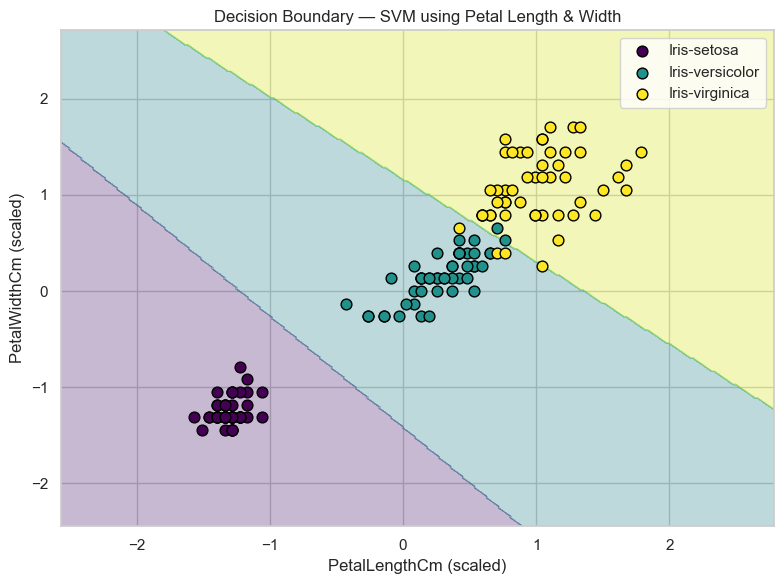

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Use the two most separating features for a 2D visual
feat_x, feat_y = "PetalLengthCm", "PetalWidthCm"
X_2d = df[[feat_x, feat_y]].values
y_2d = y_encoded

# Scale just these two features
scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

# Retrain the same type of model (SVM) on just these 2 features
boundary_model = SVC(kernel="linear")
boundary_model.fit(X_2d_scaled, y_2d)

# Build a mesh grid covering the feature space
x_min, x_max = X_2d_scaled[:, 0].min() - 1, X_2d_scaled[:, 0].max() + 1
y_min, y_max = X_2d_scaled[:, 1].min() - 1, X_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                      np.linspace(y_min, y_max, 300))

Z = boundary_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")

colors = ["#440154", "#21918c", "#fde725"]
for i, species in enumerate(le.classes_):
    mask = y_2d == i
    plt.scatter(X_2d_scaled[mask, 0], X_2d_scaled[mask, 1],
                label=species, edgecolor="black", s=60, color=colors[i])

plt.xlabel(f"{feat_x} (scaled)")
plt.ylabel(f"{feat_y} (scaled)")
plt.title("Decision Boundary — SVM using Petal Length & Width")
plt.legend()
plt.tight_layout()
plt.savefig(out("decision_boundary.png"), dpi=150)
plt.show()
plt.close()

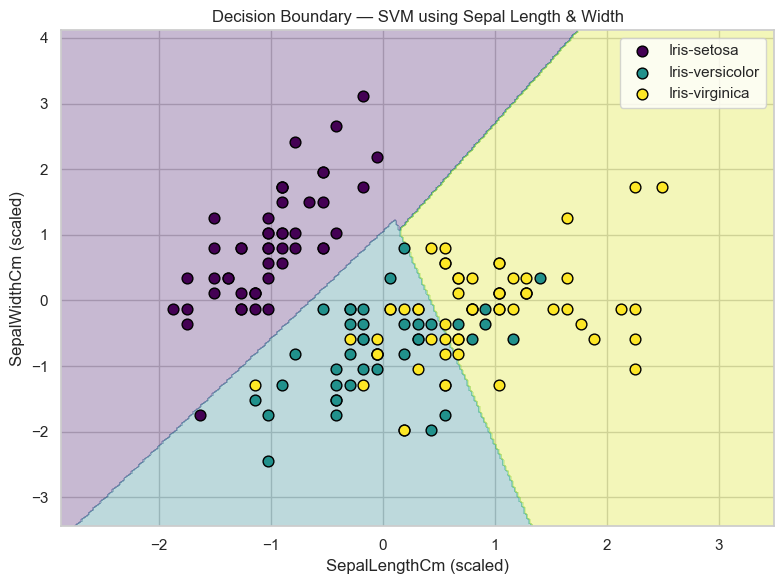

In [20]:
# Use sepal measurements instead
feat_x2, feat_y2 = "SepalLengthCm", "SepalWidthCm"
X_2d_sepal = df[[feat_x2, feat_y2]].values

# Scale
scaler_2d_sepal = StandardScaler()
X_2d_sepal_scaled = scaler_2d_sepal.fit_transform(X_2d_sepal)

# Retrain SVM on sepal features only
boundary_model_sepal = SVC(kernel="linear")
boundary_model_sepal.fit(X_2d_sepal_scaled, y_2d)

# Mesh grid
x_min, x_max = X_2d_sepal_scaled[:, 0].min() - 1, X_2d_sepal_scaled[:, 0].max() + 1
y_min, y_max = X_2d_sepal_scaled[:, 1].min() - 1, X_2d_sepal_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                      np.linspace(y_min, y_max, 300))

Z = boundary_model_sepal.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")

for i, species in enumerate(le.classes_):
    mask = y_2d == i
    plt.scatter(X_2d_sepal_scaled[mask, 0], X_2d_sepal_scaled[mask, 1],
                label=species, edgecolor="black", s=60, color=colors[i])

plt.xlabel(f"{feat_x2} (scaled)")
plt.ylabel(f"{feat_y2} (scaled)")
plt.title("Decision Boundary — SVM using Sepal Length & Width")
plt.legend()
plt.tight_layout()
plt.savefig(out("decision_boundary_sepal.png"), dpi=150)
plt.show()
plt.close()